<a href="https://colab.research.google.com/github/RoyAru11/Prob-Stat/blob/main/Metropolis_Hasting_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=[10,6]
np.random.seed(42)

In [50]:
state_space=("sunny", "cloudy", "rainy")

In [51]:
transition_matrix = np.array(((0.6, 0.3, 0.1),
                              (0.3, 0.4, 0.3),
                              (0.2, 0.3, 0.5)))

In [52]:
n_steps = 20000
states = [0]
for i in range(n_steps):
    states.append(np.random.choice((0,1,2), p=transition_matrix[states[-1]]))
states = np.array(states)

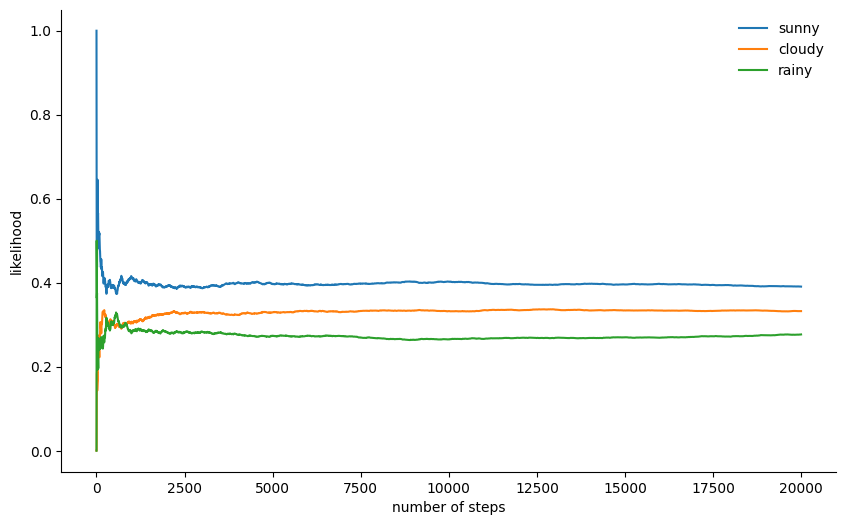

In [53]:
def despine(ax, spines=('top', 'left', 'right')):
  for spine in spines:
    ax.spines[spine].set_visible(False)

fix, ax = plt.subplots()
width = 1000
offsets = range(1, n_steps, 5)
for i, label in enumerate(state_space):
  ax.plot(offsets, [np.sum(states[:offset] == i) / offset
                    for offset in offsets], label=label)
ax.set_xlabel("number of steps")
ax.set_ylabel("likelihood")
ax.legend(frameon=False)
despine(ax, ('top', 'right'))
plt.show()

In [54]:
def log_prob(x):
  return -0.5 * np.sum(x ** 2)

In [55]:
def proposal(x, stepsize):
  return np.random.uniform(low=x - 0.5 * stepsize,
                          high=x + 0.5 * stepsize,
                          size=x.shape)

In [56]:
def p_acc_MH(x_new, x_old, log_prob):
  return min(1, np.exp(log_prob(x_new) - log_prob(x_old)))

In [57]:
def sample_MH(x_old, log_prob, stepsize):
  x_new = proposal(x_old, stepsize)
  accept = np.random.uniform() < p_acc_MH(x_new, x_old, log_prob)
  if np.random.uniform() < p_acc_MH(x_new, x_old, log_prob):
    return accept, x_new
  else:
    return accept, x_old

In [58]:
def build_MH_chain(init, stepsize, n_total, log_prob):
  n_accepted = 0
  chain = [init]

  for _ in range(n_total):
    accept, x_new = sample_MH(chain[-1], log_prob, stepsize)
    if accept:
      n_accepted += 1
    chain.append(x_new)

  acceptance_rate = n_accepted / n_total

  return chain, acceptance_rate

**Testing our Metropolis-Hastings implementation and exploring its behavior**

In [59]:
chain, acceptance_rate = build_MH_chain(np.array([2.0]), 3.0, 1000, log_prob)
chain = [state for state, in chain]

print("Acceptance rate: {:.3f}".format(acceptance_rate))
last_states = ",".join("{:.5f}".format(state)
                        for state in chain[-10:])
print("Last ten states of chain: " + last_states)

Acceptance rate: 0.695
Last ten states of chain: 0.42247,0.42247,0.42247,0.42247,1.63366,2.52286,2.22655,2.74207,2.29462,2.29462


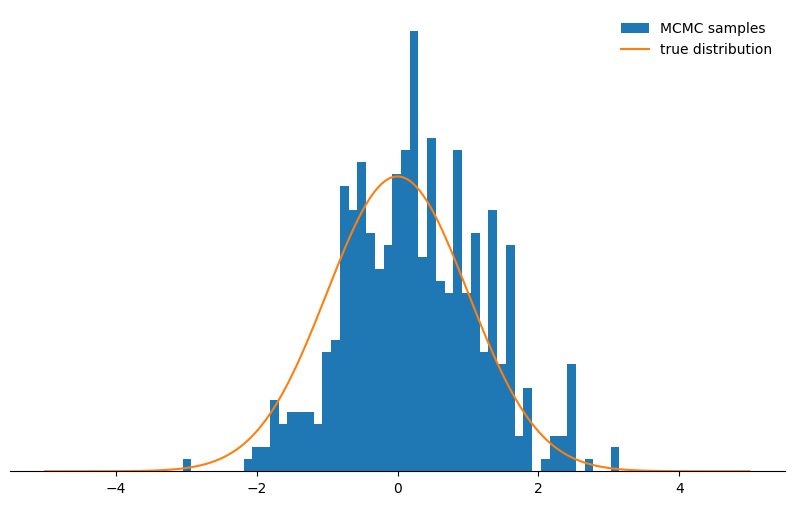

In [60]:
def plot_samples(chain, log_prob, ax, orientation='vertical', normalize=True,
                 xlims=(-5, 5), legend=True):
    from scipy.integrate import quad

    ax.hist(chain, bins=50, density=True, label="MCMC samples",
           orientation=orientation)
    # we numerically calculate the normalization constant of our PDF
    if normalize:
        Z, _ = quad(lambda x: np.exp(log_prob(x)), -np.inf, np.inf)
    else:
        Z = 1.0
    xses = np.linspace(xlims[0], xlims[1], 1000)
    yses = [np.exp(log_prob(x)) / Z for x in xses]
    if orientation == 'horizontal':
        (yses, xses) = (xses, yses)
    ax.plot(xses, yses, label="true distribution")
    if legend:
        ax.legend(frameon=False)

fig, ax = plt.subplots()
plot_samples(chain[500:], log_prob, ax)
despine(ax)
ax.set_yticks(())
plt.show()

Acceptance rate: 0.107


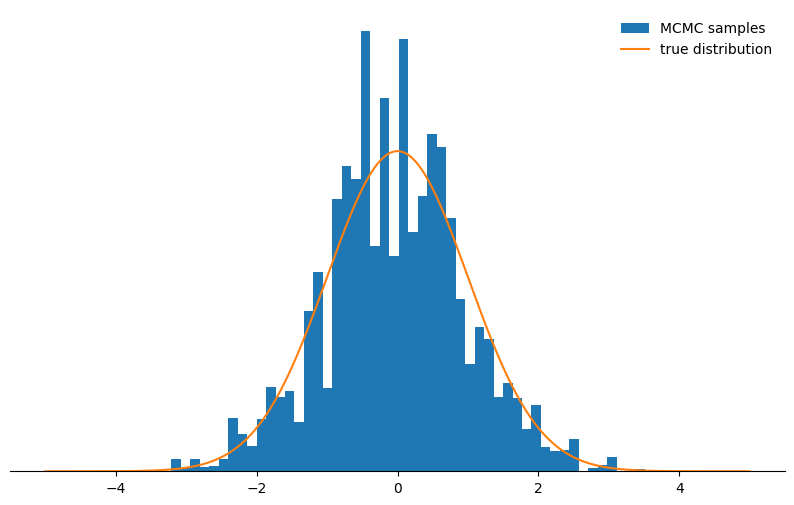

In [61]:
def sample_and_display(init_state, stepsize, n_total, n_burnin, log_prob):
  chain, acceptance_rate  = build_MH_chain(init_state, stepsize, n_total, log_prob)
  print("Acceptance rate: {:.3f}".format(acceptance_rate))
  fig, ax = plt.subplots()
  plot_samples([state for state, in chain[n_burnin:]], log_prob, ax)
  despine(ax)
  ax.set_yticks(())
  plt.show()

sample_and_display(np.array([2.0]), 30, 10000, 500, log_prob)

Acceptance rate: 0.993


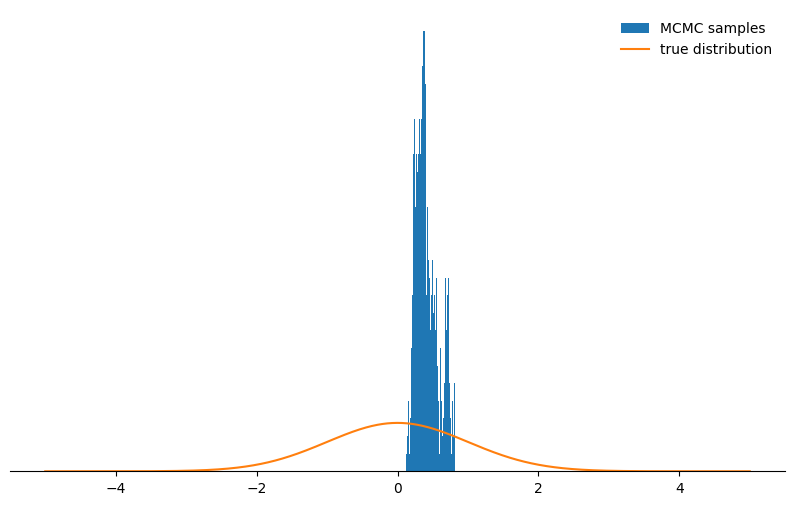

In [62]:
sample_and_display(np.array([2.0]), 0.1, 1000, 500, log_prob)

Acceptance rate: 0.990


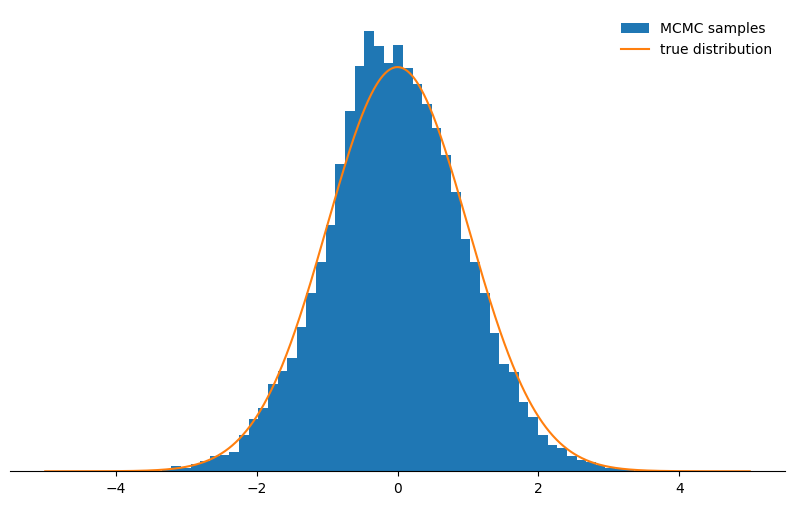

In [63]:
sample_and_display(np.array([2.0]), 0.1, 500000, 25000, log_prob)